## importing libraries

In [1]:
import numpy as np # Numerical operations and array handling
import pandas as pd # Data manipulation and analysis using DataFrame
import matplotlib.pyplot as  plt # Create a Data Visualization and plots
import seaborn as sns  # Attractive statistical visualization
import re # re- Regular Expressions for text pattern matching and cleaning
import string # like punctuation and letters
import nltk # Natural Language ToolKit for Text processing Tasks

import warnings # to manage warning messages
warnings.filterwarnings('ignore') # warining messages to keep output clean

from sklearn.model_selection import train_test_split # Split data into training and Test
from sklearn. feature_extraction.text import TfidfVectorizer # to convert text data into numerical data
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # measures a model performance
from sklearn.linear_model import LogisticRegression # for a classification task

nltk.download('stopwords') # download a common set of stopwords for textpreprocessing
from nltk.corpus import stopwords # to remove commonly used words like is, the, and
from nltk.stem import  PorterStemmer # to reduce words to a root form
from nltk.stem import WordNetLemmatizer # to convert words to their base dictionary form
nltk.download('wordnet') # for lemmatization

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shrio\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shrio\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Importing dataset

In [2]:
imdb_movie_review = pd.read_csv("IMDB Dataset.csv") # using the pandas import dataset
imdb_movie_review 

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [3]:
imdb_movie_review.info() #  checking with the null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [19]:
imdb_movie_review.duplicated().sum()

418

## Clean the review Column

In [4]:
stop_words = set(stopwords.words("english")) # stop words are stire them in a set for last lookup
ps = PorterStemmer() # reduce the words to the root 
lm = WordNetLemmatizer() # convert words to their base dictionary form

def clean_review(review): # create the  function and named it clean_review
    review = review.lower() # Convert to lowercase
    review = re.sub(r'@\w+', '', review) # Remove @mentions
    review = re.sub(r'<br/>', '', review) # Remove HTML tags
    review = re.sub(r'\d+', '', review)# Remove numbers
    review = review.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation ( . , ! ?)
    tokens = review.split() # Tokenize text
    tokens = [lm.lemmatize(word) for word in tokens if word not in stop_words]  # Lemmatize & remove stopwords
    return " ".join(tokens)


## apply Cleainnng to  the dataset

In [5]:
imdb_movie_review['clean_review'] = imdb_movie_review['review'].apply(clean_review) # apply the clean_-review

imdb_movie_review[['review','clean_review']].head() #  check the  review and clean_review column

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


## Label Encoding

In [6]:
imdb_movie_review['sentiment'].unique() # check with  the  unique values

array(['positive', 'negative'], dtype=object)

In [7]:
imdb_movie_review['sentiment']  =  imdb_movie_review['sentiment'].map({'positive':1,'negative':0}) # using map function change a object column  to numeric column

In [8]:
imdb_movie_review['sentiment'].unique() # check with the unique values

array([1, 0], dtype=int64)

In [9]:
print(imdb_movie_review['sentiment'].value_counts()) # check the sentiment  column values

sentiment
1    25000
0    25000
Name: count, dtype: int64


## Train and Test Split

In [10]:
X = imdb_movie_review['clean_review'] # X is my  feature
y= imdb_movie_review['sentiment'] # y is traget column

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42) # using a 20 % of data test data

In [11]:
len(X_train), len(X_test), len(y_train), len(y_test) # checking with the train and test  column

(40000, 10000, 40000, 10000)

## Vectorization (TF-IDF)

In [12]:
tfidf  = TfidfVectorizer(max_features=5000, ngram_range=(1,2)) # took a 5000 features column to convert text to numberic column using unigrams and bigrams
X_train_tfidf = tfidf.fit_transform(X_train) # fit and transform the trian data 
X_test_tfidf = tfidf.transform(X_test) #  transform the  test data

## model Training (Logistic Regression)

In [13]:
model = LogisticRegression(max_iter=1000)  # import logistic regressor  using limit of 1000
model.fit(X_train_tfidf, y_train) # train the logistic model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## predictions and ecaluation

Accuracy : 0.8888

Classification Report : 
               precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



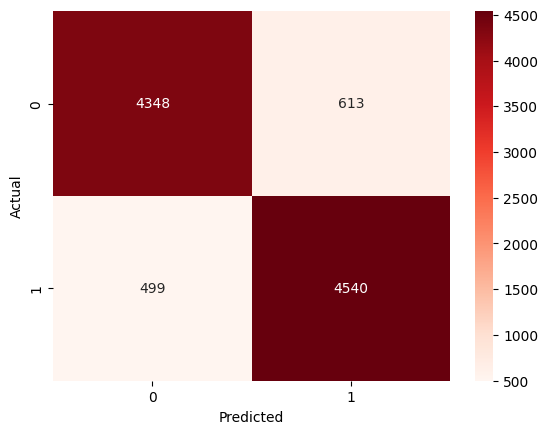

In [14]:
y_pred =  model.predict(X_test_tfidf) # using the logistic mmodel prediting the value

print("Accuracy :",accuracy_score(y_test,y_pred)) # calculates the  accuaracy score
print("\nClassification Report : \n", classification_report(y_test, y_pred)) # display the precision, recall, f1 score

cm = confusion_matrix(y_test, y_pred) #  confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap="Reds") # using heatmap importing the confusion matrix
plt.xlabel("Predicted") # x label assign the values
plt.ylabel("Actual") # y labbel assign the values
plt.show()  #  disply the plot

## predict  sentiment for new review

In [15]:
def  predict_sentiments(review): #  create a predict function assign  the  review column
    cleaned =  clean_review(review) 
    vector  = tfidf.transform([cleaned])
    pred = model.predict(vector)[0]
    labels = ({0:'negative',1:'positive'})
    return labels[pred]

## output of Sentiments

In [16]:
sample = "A wonderful little production"
print(predict_sentiments(sample))

positive


In [17]:
sample  = "No one expects the Star Trek movies "
print(predict_sentiments(sample))

negative


## important words for each sentiments

In [18]:

words = np.array(tfidf.get_feature_names_out())
coef = model.coef_
N = 20

def show_top_words(class_index, class_name):
    print("")
    print("")
    print("TOP " + str(N) + " WORDS FOR " + class_name.upper() + " ")
    
    top_idx = np.argsort(coef[class_index])[-N:]
    top_words = words[top_idx]
    
    for w in reversed(top_words):
        print(w)

show_top_words(0, "Negative")
show_top_words(1, "Positive")




TOP 20 WORDS FOR NEGATIVE 
excellent
great
perfect
amazing
wonderful
brilliant
favorite
hilarious
loved
one best
best
superb
fantastic
enjoyable
today
entertaining
enjoyed
definitely
perfectly
highly


TOP 20 WORDS FOR POSITIVE 


IndexError: index 1 is out of bounds for axis 0 with size 1